# Baseline Metrics: Diversity, Perplexity, Coherence, Q*Text

- Single-text automatic metrics from the open-ended text generation literature
- Computed on **human_drift** storytelling
- External baselines to contextualize the credal-set diversity vector
- Definitions from Garces Arias et al., 2025: Towards Better Open-Ended Text Generation: A Multicriteria Evaluation Framework (GEM² 2025)

| Metric | Formula | Direction |
|---|---|---|
| Diversity | $\text{DIV}(x) = \prod_{n=2}^{4} \dfrac{\lvert\text{unique } n\text{-grams}(x)\rvert}{\lvert\text{total } n\text{-grams}(x)\rvert}$ | higher = more lexically varied |
| Perplexity | $P(W) = \exp\left(-\dfrac{1}{N}\sum_{i=1}^N \log p(w_i \mid w_1,\dots,w_{i-1})\right)$ | lower = more predictable/fluent |
| Coherence | $\text{Coherence}(\hat x, x) = \dfrac{1}{\lvert\hat x\rvert}\sum_{i=1}^{\lvert\hat x\rvert}\log p_M(\hat x_i \mid [x:\hat x_{<i}])$ | higher = better conditioned on prompt |
| Q*Text | $\dfrac{\sum_{i=1}^{3} w_i M_i P_i(M_i)}{\sum_{i=1}^{3} w_i}$, with $P_i(x)=\exp(-\alpha_i(x-\mu_i)^2)$ | 0–100, weighted combination of the three metrics above |

**Deviations from the paper:**
- **GPT-2-large** as a fixed external scorer for Coherence and Perplexity
- Q*Text reuses the paper's published fitted parameters (Table 21) rather than refitting them on this data

In [1]:
# Load libraries
import json
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal
from transformers import AutoModelForCausalLM, AutoTokenizer
from tqdm import tqdm

warnings.filterwarnings('ignore')
np.random.seed(42)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

tqdm.pandas()

/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/Masterthesis/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Configuration
N_PROMPTS = 100
TASK_FILTER = 'storytelling'
SOURCES = ['human', 'llama', 'mistral', 'qwen', 'gemma']
SOURCE_COLORS = {
    'human': '#1565C0', 'llama': '#E65100',
    'mistral': '#6A1B9A', 'qwen': '#2E7D32', 'gemma': '#C62828',
}

# Load data
DATA_DIR = Path('../../data/human_drift/clean_generations')
FIG_DIR = Path('../../figures/baseline_metrics')
FIG_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = 'gpt2-large'   # proxy scorer for Coherence & Perplexity (paper uses OPT-2.7B for Coherence)
MAX_TOKENS = 256            # matches the paper's generation length cap
DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

print('Configuration:')
print(f'  Sources:    {SOURCES}')
print(f'  Task:       {TASK_FILTER}')
print(f'  Scorer:     {MODEL_NAME} on {DEVICE}')
print(f'  Max tokens: {MAX_TOKENS}')

Configuration:
  Sources:    ['human', 'llama', 'mistral', 'qwen', 'gemma']
  Task:       storytelling
  Scorer:     gpt2-large on mps
  Max tokens: 256


## Load Dataset

In [4]:
rows = []
for source in SOURCES:
    fp = DATA_DIR / f'{source}_{TASK_FILTER}_clean.json'
    with open(fp) as f:
        raw = json.load(f)
    prompts = list(raw.keys())[:N_PROMPTS]
    for prompt_id, prompt_text in enumerate(prompts):
        for story_id, text in enumerate(raw[prompt_text]):
            rows.append({
                'prompt_id': prompt_id,
                'source': source,
                'story_id': story_id,
                'task': TASK_FILTER,
                'prompt': prompt_text,
                'text': text,
            })

df = pd.DataFrame(rows)
print(f'Loaded: {len(df)} texts ({df["prompt_id"].nunique()} prompts × {len(SOURCES)} sources)')
print(df.groupby('source').size())
df.head(3)

Loaded: 4994 texts (100 prompts × 5 sources)
source
gemma      1000
human      1000
llama      1000
mistral    1000
qwen        994
dtype: int64


,prompt_id,source,story_id,task,prompt,text
0,0,human,0,storytelling,[ WP ] Leonardo DiCaprio in a fit of rage begi...,The wet marble floor pressed on his cheek like...
1,0,human,1,storytelling,[ WP ] Leonardo DiCaprio in a fit of rage begi...,Year after year the Oscar had eluded DiCaprio....
2,0,human,2,storytelling,[ WP ] Leonardo DiCaprio in a fit of rage begi...,Leo stood there in perfect silence. The hushed...


## Diversity — n-gram Repetition Rates

$$\text{DIV}(x) = \prod_{n=2}^{4} \frac{|\text{unique } n\text{-grams}(x)|}{|\text{total } n\text{-grams}(x)|}$$

- Purely lexical, no model needed
- Word tokens via simple regex (`\w+`, lowercased), consistent with the standard distinct-*n* family of diversity metrics

In [5]:
# Word tokenizer
def word_tokenize_simple(text):
    return re.findall(r"\w+", text.lower())

def diversity_score(text, n_range=(2, 3, 4)):
    '''Calculate the diversity score of a text based on unique n-grams for n in n_range.'''
    tokens = word_tokenize_simple(text)
    score = 1.0
    for n in n_range:
        # Only consider n-grams if there are enough tokens
        if len(tokens) < n:
            return np.nan
        # Create n-grams
        ngrams = list(zip(*(tokens[i:] for i in range(n))))
        unique = len(set(ngrams))
        # Calculate the diversity score as the ratio of unique n-grams to total n-grams
        score *= unique / len(ngrams)
    return score


df['Diversity'] = df['text'].progress_apply(diversity_score)
print(df['Diversity'].describe())

100%|██████████| 4994/4994 [00:00<00:00, 7664.92it/s]

count    4994.000000
mean        0.874612
std         0.095031
min         0.000032
25%         0.836988
50%         0.894314
75%         0.933711
max         1.000000
Name: Diversity, dtype: float64


## Load the Fixed External Scorer (GPT-2-large)

In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(DEVICE)
model.eval()
print(f'{MODEL_NAME} loaded on {DEVICE} (context window: {model.config.n_positions} tokens)')

Loading weights: 100%|██████████| 436/436 [00:00<00:00, 10218.23it/s]


gpt2-large loaded on mps (context window: 1024 tokens)


## Perplexity — Self-Predictability of the Continuation

- Computed on generated text alone (no prompt context), truncated to `MAX_TOKENS`
- Uses GPT-2-large's built-in cross-entropy loss ( = mean negative log-likelihood over the shifted sequence)

In [7]:
@torch.no_grad()
def compute_perplexity(text, max_tokens=MAX_TOKENS):
    ''' Compute the perplexity of a text using a GPT-2 model. Returns NaN if the text is too short.'''
    # Input text to model and compute loss
    input_ids = tokenizer(text, return_tensors='pt', truncation=True, max_length=max_tokens)['input_ids'].to(DEVICE)
    # Only compute perplexity if the text has at least 2 tokens
    if input_ids.shape[1] < 2:
        return np.nan
    # Compute the loss and convert it to perplexity
    loss = model(input_ids, labels=input_ids).loss
    return float(torch.exp(loss).cpu())

# Load or compute perplexity
CACHE_PATH = Path('baseline_metrics_results.csv')
KEY_COLS = ['prompt_id', 'source', 'story_id']

if CACHE_PATH.exists():
    cached = pd.read_csv(CACHE_PATH)[KEY_COLS + ['Perplexity']]
    df = df.merge(cached, on=KEY_COLS, how='left')
    print(f'Loaded cached Perplexity for {df["Perplexity"].notna().sum()}/{len(df)} texts (skipped recomputation)')
else:
    df['Perplexity'] = df['text'].progress_apply(compute_perplexity)
print(df['Perplexity'].describe())

Loaded cached Perplexity for 4994/4994 texts (skipped recomputation)
count    4994.000000
mean       14.712653
std         8.856805
min         1.980634
25%         9.464495
50%        11.657402
75%        16.052213
max        80.699799
Name: Perplexity, dtype: float64


## Coherence — Log-Likelihood of the Continuation Given the Prompt

$$\text{Coherence}(\hat x, x) = \frac{1}{|\hat x|}\sum_{i=1}^{|\hat x|} \log p_M(\hat x_i \mid [x : \hat x_{<i}])$$

Prompt and continuation are each truncated to `MAX_TOKENS`, concatenated, and only the log-probabilities of the continuation tokens (conditioned on the prompt) are averaged.

In [8]:
@torch.no_grad()
def compute_coherence(prompt, text, max_tokens=MAX_TOKENS):
    ''' Compute the coherence of a text given a prompt using a GPT-2 model. Returns NaN if the text is too short.'''
    # Tokenize the prompt
    prompt_ids = tokenizer(prompt, return_tensors='pt', truncation=True, max_length=max_tokens)['input_ids']
    # Tokenize the continuation text and check if it has at least 1 token
    cont_ids = tokenizer(text, return_tensors='pt', truncation=True, max_length=max_tokens)['input_ids']
    if cont_ids.shape[1] < 1:
        return np.nan
    
    # Concatenate prompt and continuation
    input_ids = torch.cat([prompt_ids, cont_ids], dim=1)
    prompt_len = prompt_ids.shape[1]

    # Ensure the input does not exceed the model's context window
    ctx_limit = model.config.n_positions
    if input_ids.shape[1] > ctx_limit:
        overflow = input_ids.shape[1] - ctx_limit
        input_ids = input_ids[:, overflow:]
        prompt_len = max(prompt_len - overflow, 0)

    # Compute the log probabilities of the continuation tokens given the prompt
    input_ids = input_ids.to(DEVICE)
    logits = model(input_ids).logits
    log_probs = torch.log_softmax(logits[:, :-1, :], dim=-1)
    targets = input_ids[:, 1:]
    token_log_probs = log_probs.gather(2, targets.unsqueeze(-1)).squeeze(-1)

    # Compute the mean log probability of the continuation tokens
    cont_start = max(prompt_len - 1, 0)
    cont_log_probs = token_log_probs[:, cont_start:]
    if cont_log_probs.shape[1] == 0:
        return np.nan
    return float(cont_log_probs.mean().cpu())


# Load or compute coherence
if CACHE_PATH.exists():
    cached = pd.read_csv(CACHE_PATH)[KEY_COLS + ['Coherence']]
    df = df.merge(cached, on=KEY_COLS, how='left')
    print(f'Loaded cached Coherence for {df["Coherence"].notna().sum()}/{len(df)} texts (skipped recomputation)')
else:
    df['Coherence'] = df.progress_apply(lambda r: compute_coherence(r['prompt'], r['text']), axis=1)
print(df['Coherence'].describe())

Loaded cached Coherence for 4994/4994 texts (skipped recomputation)
count    4994.000000
mean       -2.559955
std         0.457245
min        -4.395636
25%        -2.765722
50%        -2.446190
75%        -2.250085
max        -0.645836
Name: Coherence, dtype: float64


## Save Results

In [9]:
out_path = 'baseline_metrics_results.csv'

df[['prompt_id', 'source', 'story_id', 'Diversity', 'Perplexity', 'Coherence']].to_csv(
    out_path.replace('.csv', '_summary.csv'), index=False
)
df.to_csv(out_path, index=False)

print(f'Saved baseline metrics to: {out_path}')
df.head(5)

Saved baseline metrics to: baseline_metrics_results.csv


,prompt_id,source,story_id,task,prompt,text,Diversity,Perplexity,Coherence
0,0,human,0,storytelling,[ WP ] Leonardo DiCaprio in a fit of rage begi...,The wet marble floor pressed on his cheek like...,0.879093,40.050415,-3.732006
1,0,human,1,storytelling,[ WP ] Leonardo DiCaprio in a fit of rage begi...,Year after year the Oscar had eluded DiCaprio....,0.880135,45.095463,-3.687838
2,0,human,2,storytelling,[ WP ] Leonardo DiCaprio in a fit of rage begi...,Leo stood there in perfect silence. The hushed...,0.973568,28.704216,-3.316015
3,0,human,3,storytelling,[ WP ] Leonardo DiCaprio in a fit of rage begi...,'Well?' \n \n'Well what?' \n \n'Is it real?' \...,0.943203,22.073494,-3.033572
4,0,human,4,storytelling,[ WP ] Leonardo DiCaprio in a fit of rage begi...,*Blart 3D Gets Lost in the Food Court* | July ...,0.938176,39.903008,-3.602979


## Descriptive Analysis by Source

In [10]:
METRICS = ['Diversity', 'Perplexity', 'Coherence']

summary = df.groupby('source')[METRICS].agg(['mean', 'std']).round(3)
summary = summary.loc[SOURCES]
summary

Diversity        Perplexity         Coherence       
             mean    std       mean     std      mean    std
source                                                      
human       0.885  0.070     28.292  10.959    -3.258  0.372
llama       0.822  0.104      9.125   1.815    -2.191  0.211
mistral     0.818  0.089     10.634   2.086    -2.339  0.185
qwen        0.934  0.033     10.830   2.360    -2.358  0.194
gemma       0.915  0.095     14.659   3.359    -2.653  0.260

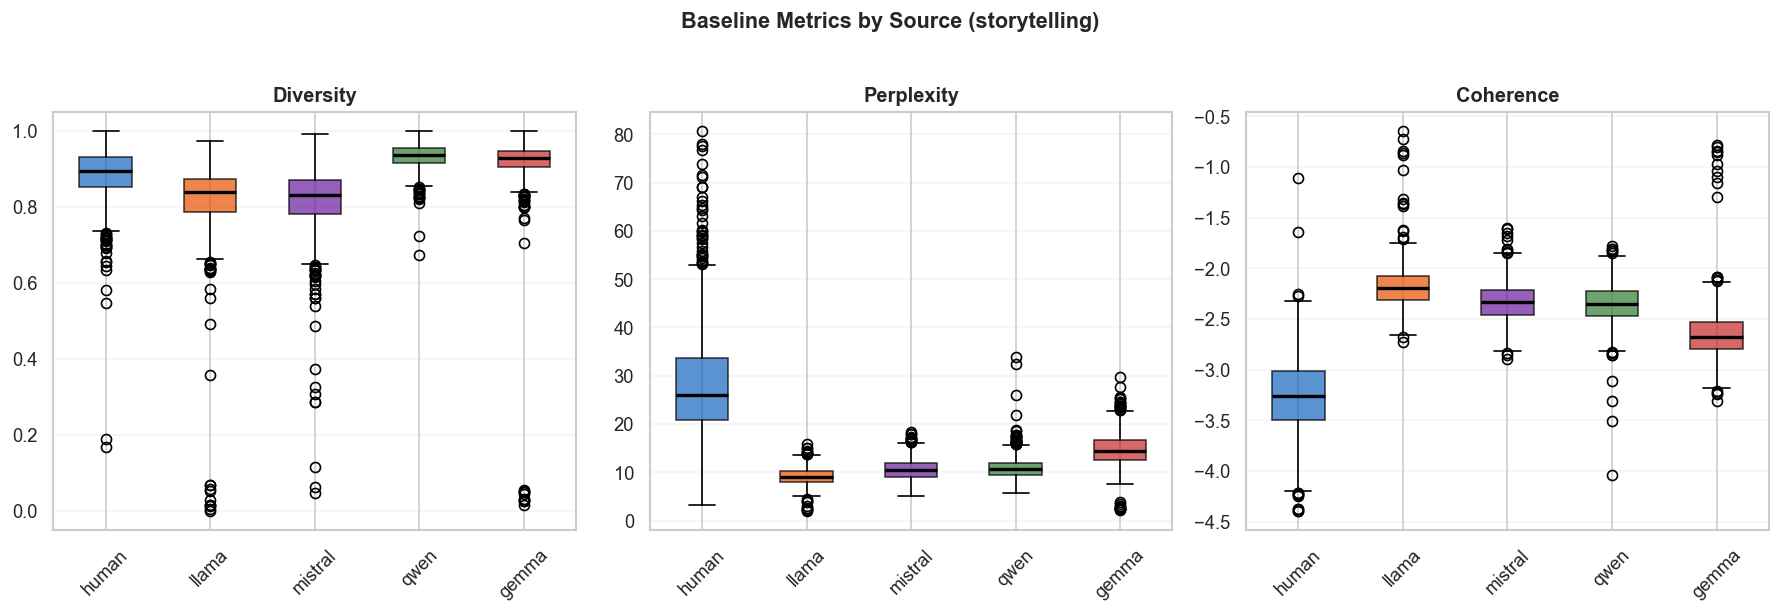

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric in zip(axes, METRICS):
    data_plot = [df[df['source'] == s][metric].dropna().values for s in SOURCES]
    bp = ax.boxplot(data_plot, labels=SOURCES, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
    for patch, source in zip(bp['boxes'], SOURCES):
        patch.set_facecolor(SOURCE_COLORS[source])
        patch.set_alpha(0.7)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.2, axis='y')

fig.suptitle('Baseline Metrics by Source (storytelling)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'baseline_metrics_by_source.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
print('Kruskal-Wallis Test: Baseline Metric Differences across Sources\n')
print(f'{"Metric":<12} {"H-stat":>10} {"p-value":>12} {"Significant (α=0.05)":>22}')
print('-' * 58)

for metric in METRICS:
    groups = [df[df['source'] == s][metric].dropna().values for s in SOURCES]
    stat, p = kruskal(*groups)
    sig = '✓' if p < 0.05 else '✗'
    print(f'{metric:<12} {stat:>10.2f} {p:>12.4f} {sig:>22}')

Kruskal-Wallis Test: Baseline Metric Differences across Sources

Metric           H-stat      p-value   Significant (α=0.05)
----------------------------------------------------------
Diversity       2297.41       0.0000                      ✓
Perplexity      3264.77       0.0000                      ✓
Coherence       3322.77       0.0000                      ✓


## Metric Intercorrelations

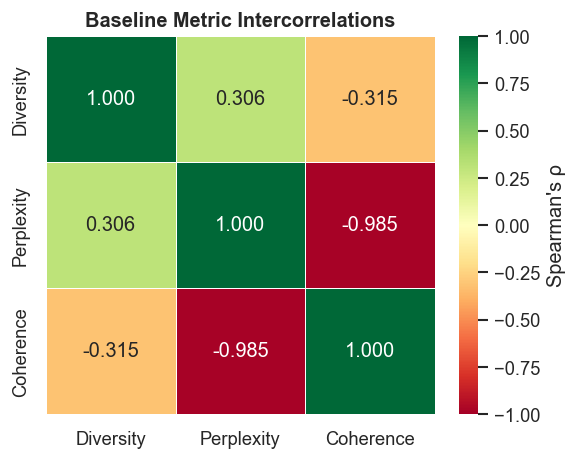

In [13]:
corr_df = df[METRICS].dropna()
rho_matrix = corr_df.corr(method='spearman')

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(rho_matrix, annot=True, fmt='.3f', cmap='RdYlGn', vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, cbar_kws={'label': "Spearman's ρ"})
ax.set_title('Baseline Metric Intercorrelations', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'baseline_metrics_intercorrelation.png', dpi=300, bbox_inches='tight')
plt.show()

## Q*Text — Unified Quality Score (Garces Arias et al., 2025)

$$\text{Q*Text} = \frac{\sum_{i=1}^{3} w_i M_i P_i(M_i)}{\sum_{i=1}^{3} w_i}, \qquad P_i(x) = \exp(-\alpha_i (x-\mu_i)^2)$$

- $M_1, M_2, M_3$ are Perplexity, Coherence, and Diversity, each min-max normalized to $[0,1]$ over this dataset (Perplexity inverted so higher = better)
- $w_i$, $\mu_i$, $\alpha_i$ are weights, target values and penalty strengths per metric
- Result ×100 to match the paper's reported score range

**Parameters — the paper's own fitted values**:

| | Perplexity ($i=1$) | Coherence ($i=2$) | Diversity ($i=3$) |
|---|---|---|---|
| $w_i$ | 0.586 | 0.834 | 3.853 |
| $\mu_i$ | 0.458 | 0.000 | 0.854 |
| $\alpha_i$ | 2.579 | 1.496 | 7.370 |

In [14]:
# Fitted hyperparameters from Garces Arias et al. (2025), Table 21
Q_STAR_PARAMS = {
    # order in each tuple: (Perplexity, Coherence, Diversity)
    'w':     (0.586, 0.834, 3.853),   # weight: how much each metric contributes to the final score
    'mu':    (0.458, 0.000, 0.854),   # target: the "ideal" normalized value for each metric
    'alpha': (2.579, 1.496, 7.370),   # penalty strength: how sharply the score drops away from mu
}


def gaussian_penalty(x, mu, alpha):
    """P_i(x) = exp(-alpha * (x - mu)^2).

    Equals 1.0 at x == mu and decays towards 0 the further x is from mu.
    Large alpha -> narrow peak (strict), small alpha -> wide peak (lenient).
    This is what lets Q*Text punish *extreme* metric values, not just reward high ones
    (e.g. a story that is maximally diverse but incoherent gets penalized, not rewarded).
    """
    return np.exp(-alpha * (x - mu) ** 2)


def compute_qstar(perplexity, coherence, diversity, params=Q_STAR_PARAMS):
    # Step 1 — normalize each raw metric to [0, 1] over the current dataset (dataset-relative
    # min-max, exactly as in the paper's §5.1), so all three become directly comparable and
    # "higher = better" for all of them.
    p_min, p_max = perplexity.min(), perplexity.max()
    c_min, c_max = coherence.min(), coherence.max()
    d_min, d_max = diversity.min(), diversity.max()

    m1 = (p_max - perplexity) / (p_max - p_min)   # Perplexity: raw LOWER is better -> flip direction
    m2 = (coherence - c_min) / (c_max - c_min)     # Coherence: raw higher is better -> standard min-max
    m3 = (diversity - d_min) / (d_max - d_min)     # Diversity: raw higher is better -> standard min-max

    w1, w2, w3 = params['w']
    mu1, mu2, mu3 = params['mu']
    a1, a2, a3 = params['alpha']

    # Step 2 — apply the Gaussian penalty to each normalized metric. This is the "quality
    # control" step: a metric only counts fully if it's close to its target (mu); values far
    # from the target get down-weighted even though the raw M_i value itself looks high.
    p1 = gaussian_penalty(m1, mu1, a1)
    p2 = gaussian_penalty(m2, mu2, a2)
    p3 = gaussian_penalty(m3, mu3, a3)

    # Step 3 — weighted average of (metric value * its own penalty). Multiplying by 100 matches
    # the score range reported in the paper's Table 4 (human-written reference ~87, degenerate
    # generations near 0); the formula itself would otherwise stay in [0, 1].
    numerator = w1 * m1 * p1 + w2 * m2 * p2 + w3 * m3 * p3
    return 100 * numerator / (w1 + w2 + w3)


df['QStarText'] = compute_qstar(df['Perplexity'], df['Coherence'], df['Diversity'])
print(df['QStarText'].describe())

count    4994.000000
mean       72.581834
std         7.648451
min         8.754535
25%        71.992497
50%        75.342960
75%        76.462516
max        76.989177
Name: QStarText, dtype: float64


In [15]:
# Overwrite the results CSVs
df.to_csv('baseline_metrics_results.csv', index=False)
df[['prompt_id', 'source', 'story_id', 'Diversity', 'Perplexity', 'Coherence', 'QStarText']].to_csv(
    'baseline_metrics_results_summary.csv', index=False
)
print('Updated baseline_metrics_results.csv / _summary.csv with QStarText')

Updated baseline_metrics_results.csv / _summary.csv with QStarText


In [16]:
# Mean/std of all four metrics per source, same layout as the earlier summary table
ALL_METRICS = METRICS + ['QStarText']

summary_q = df.groupby('source')[ALL_METRICS].agg(['mean', 'std']).round(3)
summary_q = summary_q.loc[SOURCES]
summary_q

Diversity        Perplexity         Coherence        QStarText       
             mean    std       mean     std      mean    std      mean    std
source                                                                       
human       0.885  0.070     28.292  10.959    -3.258  0.372    72.653  5.461
llama       0.822  0.104      9.125   1.815    -2.191  0.211    69.624  9.278
mistral     0.818  0.089     10.634   2.086    -2.339  0.185    69.066  9.335
qwen        0.934  0.033     10.830   2.360    -2.358  0.194    76.140  1.299
gemma       0.915  0.095     14.659   3.359    -2.653  0.260    75.448  6.761

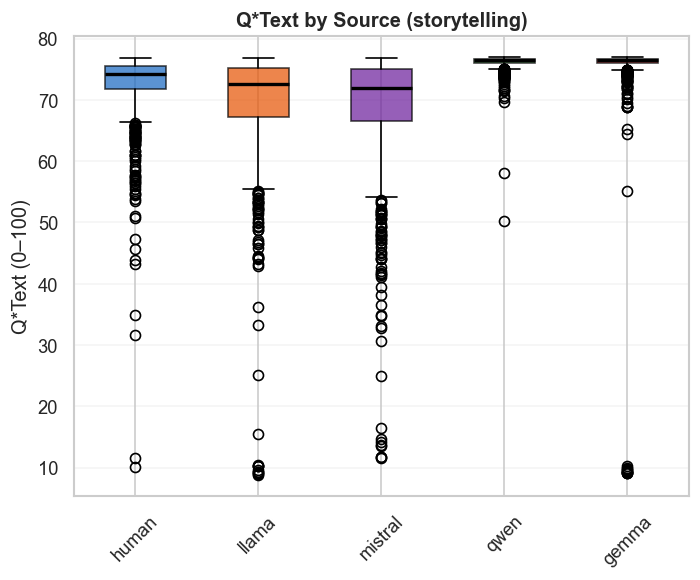

In [17]:
# Boxplot of Q*Text per source, same style as the Diversity/Perplexity/Coherence boxplots above
fig, ax = plt.subplots(figsize=(6, 5))
data_plot = [df[df['source'] == s]['QStarText'].dropna().values for s in SOURCES]
bp = ax.boxplot(data_plot, labels=SOURCES, patch_artist=True,
                 medianprops=dict(color='black', linewidth=2))
for patch, source in zip(bp['boxes'], SOURCES):
    patch.set_facecolor(SOURCE_COLORS[source])
    patch.set_alpha(0.7)
ax.set_title('Q*Text by Source (storytelling)', fontsize=12, fontweight='bold')
ax.set_ylabel('Q*Text (0–100)')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.savefig(FIG_DIR / 'qstartext_by_source.png', dpi=300, bbox_inches='tight')
plt.show()

In [18]:
# Significance test for Q*Text across sources (Kruskal-Wallis tests)
groups = [df[df['source'] == s]['QStarText'].dropna().values for s in SOURCES]
stat, p = kruskal(*groups)
sig = '✓' if p < 0.05 else '✗'
print('Kruskal-Wallis Test: Q*Text Differences across Sources\n')
print(f'{"Metric":<12} {"H-stat":>10} {"p-value":>12} {"Significant (α=0.05)":>22}')
print('-' * 58)
print(f'{"QStarText":<12} {stat:>10.2f} {p:>12.4f} {sig:>22}')

Kruskal-Wallis Test: Q*Text Differences across Sources

Metric           H-stat      p-value   Significant (α=0.05)
----------------------------------------------------------
QStarText       2183.70       0.0000                      ✓


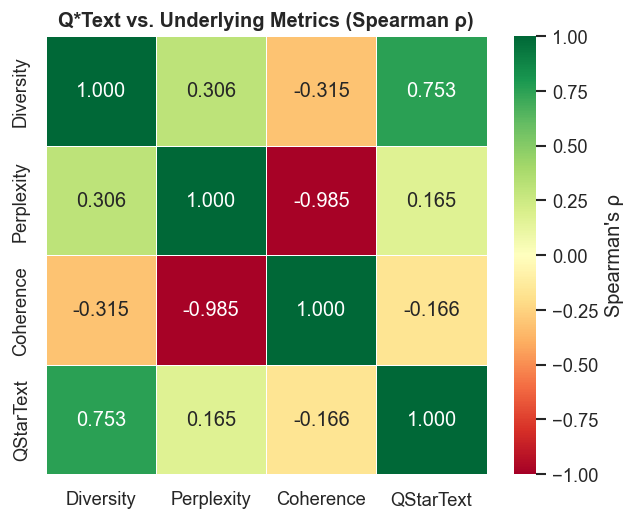

In [19]:
corr_all = df[['Diversity', 'Perplexity', 'Coherence', 'QStarText']].dropna().corr(method='spearman')

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(corr_all, annot=True, fmt='.3f', cmap='RdYlGn', vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, cbar_kws={'label': "Spearman's ρ"})
ax.set_title('Q*Text vs. Underlying Metrics (Spearman ρ)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'qstartext_intercorrelation.png', dpi=300, bbox_inches='tight')
plt.show()